In [55]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

# =========================================================
# GLOBAL CONFIGURATION (rcParams)
# =========================================================

# 1. FONT AND TEXT SETTINGS
# ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Lato', 'DejaVu Sans'],  # Priority list of clean fonts
    'font.size': 11,                                                   # Base font size for all elements

    # Specific settings for titles and axes
    'axes.titlesize': 15,                                              # Larger plot title size
    'axes.titleweight': 'bold',                                        # Bold title for emphasis
    'axes.labelsize': 13,                                              # Axis labels size (larger than base)
    'legend.fontsize': 11,                                             # Legend text size
})


# 2. AXES, TICKS, AND GRID SETTINGS
# ---
plt.rcParams.update({
    # GRID: Light and non-intrusive
    'axes.grid': True,              # Enable grid by default
    'grid.linestyle': '--',         # Dashed grid lines
    'grid.color': 'lightgray',      # Light color for grid
    'grid.alpha': 0.7,              # Transparency for grid

    # AXES SPINES (The box outline)
    'axes.spines.right': True,      # Draw right spine
    'axes.spines.top': True,        # Draw top spine
    'axes.edgecolor': 'black',      # Black color for the box outline
    'axes.linewidth': 1.2,          # Thickness of the box outline

    # MAJOR TICKS (The main markings with numbers)
    'xtick.direction': 'in',        # Major ticks pointing inwards
    'ytick.direction': 'in',
    'xtick.major.size': 6,          # Major tick length
    'ytick.major.size': 6,
    'xtick.top': True,              # Draw major ticks on the top side
    'ytick.right': True,            # Draw major ticks on the right side
    'xtick.labeltop': True,         # Show numbers on the upper X axis
    'ytick.labelright': True,       # Show numbers on the right Y axis
    
    # MINOR TICKS (Small markings between major ticks)
    'xtick.minor.visible': True,    # Enable minor ticks
    'ytick.minor.visible': True,
    'xtick.minor.top': True,        # Draw minor ticks on the top side
    'ytick.minor.right': True,
    'xtick.minor.size': 4,          # Minor tick length
    'xtick.minor.width': 0.8,       # Minor tick thickness
    'ytick.minor.width': 0.8,
})


# 3. LINES AND MARKERS SETTINGS
# ---
plt.rcParams.update({
    'lines.linewidth': 2.0,         # Default thickness for primary plot lines
    'lines.markersize': 4,          # Default size for data markers
    'lines.markeredgewidth': 1.0,   # Controls marker border thickness AND errorbar caps
})


# 4. ERRORBAR SETTINGS
# ---
plt.rcParams.update({
    'errorbar.capsize': 0.0,        # Length of the horizontal "caps" at the ends
})


# 5. LEGEND AND SAVING SETTINGS
# ---
plt.rcParams.update({
    # High-quality export settings (Best for a thesis)
    'figure.dpi': 300,              # Default display resolution (high quality)
    'savefig.format': 'png',        # Default save format to PNG (Vector format)
    'savefig.bbox': 'tight',        # Automatically trim excess white space
    'savefig.pad_inches': 0.05,     # Small padding to prevent clipping

    # Legend Appearance
    'legend.frameon': True,         # Draw a box around the legend
    'legend.edgecolor': 'lightgray',# Light border for the legend box
    'legend.fancybox': True,        # Slightly rounded legend border
})

In [56]:
equil_step = 5000
acf_step = 10000

<h1><span style="color:orange">Numerical Simulation Laboratory (NSL)</span></h1>

<h2><span style="color:green">Numerical Exercise 7</span></h2>

In this notebook, we will finalize our simulation framework for systems governed by statistical mechanics. This exercise allows us to consolidate all the fundamental components that must be managed and monitored during any simulation, whether it utilizes Monte Carlo methods or other techniques.

We will focus on simulating a Lennard-Jones fluid in two distinct statistical ensembles using two different computational approaches. We will simulate the **Microcanonical (NVE) ensemble** by means of **Molecular Dynamics (MD)** and the **Canonical (NVT) ensemble** using **Monte Carlo (MCMC) methods** based on Boltzmann sampling.

These parallel simulations will allow us to draw significant conclusions regarding the **equivalence of statistical ensembles**. We will demonstrate that a microscopic, dynamical description (the NVE ensemble) yields the same macroscopic thermodynamic averages as a probabilistic, statistical description (the NVT ensemble). This comparison provides a powerful validation of the fundamental postulates of statistical mechanics, illustrating the consistency between time-averages (from MD) and ensemble-averages (from MC).

This notebook is divided into four main sections:

1. [Implementation of **tail corrections**](#tail-corrections) for the potential energy and pressure of our statistical system.

2. [Calculation and analysis of the autocorrelation function](#autocorr-func) for the potential energy, used to determine the correlation time of the simulated process.

3. [Estimation and analysis of the statistical uncertainty (Data Blocking)](#data-blocking-error) of the mean potential energy as a function of block size, to identify the minimum block size required for statistically independent and reliable error estimates.

4. [Implementation and sampling of the **radial distribution function** ($g(r)$)](#radial-distr-func), a fundamental microscopic quantity that bridges the microscopic structure of the fluid with its macroscopic thermodynamic properties.


<h3><span style="color:darkviolet">Radial Distribution Function $g\left(\mathbf{r}_i, \mathbf{r}_j\right)$</span></h3>

In statistical mechanics, the two-body **radial distribution function**, $g(r)$, is defined as the ratio of the probability of finding two particles at a given distance $r$ in an interacting system to the probability of finding two particles at the same distance in an **ideal gas**.

In an ideal gas, particles are non-interacting, and their positions are completely uncorrelated. The probability of finding a particle at any position is uniform. The $g(r)$ therefore measures the **structural deviation** of an interacting fluid from this perfectly uniform, random distribution.

It is a fundamental quantity because:

1. It provides **direct microscopic information** about the system's structure, describing how the local density of particles varies as a function of distance from a central reference particle.

2. It is **experimentally measurable**, as it is the Fourier transform of the **static structure factor**, $S(q)$, which is directly measured in X-ray and neutron scattering experiments on condensed matter.

3. It **simplifies the calculation of ensemble-averaged thermodynamic properties**, such as potential energy and pressure.


<div style="text-align: center;">
<img src="images/rdf.png" alt="NVT ensamble" width="600">
</div>


For a liquid described by the Lennard-Jones potential, the $g(r)$ exhibits characteristic features:

- For $r < \sigma$, the probability $g(r)$ is essentially zero. This is the **excluded volume region**, where the L-J potential is strongly repulsive ($r^{-12}$), making it nearly impossible for two particles to be this close.

- A sharp, primary peak is observed at $r \approx \sigma$, **near** (but not exactly at) the minimum of the L-J potential. This peak represents the first **solvation shell**.

- This peak is followed by a **local minimum**, created because the high probability of the first shell "empties" the adjacent region.

- A second, broader maximum follows, corresponding to the **second-neighbor shell**.

- At larger distances, the function's oscillations decay, and $g(r)$ converges to $1$. This signifies that at large separations, the system becomes uncorrelated, just like an ideal gas.

To define $g(r)$ formally, one must first introduce the $n$-particle density function for a system of $N$ particles:

$$\rho^{(n)}_N(\mathbf{r}_1, \ldots, \mathbf{r}_n) = \frac{N!}{(N-n)!} \int d\mathbf{r}_{n+1}\ldots d\mathbf{r}_N~\frac{e^{-\beta \mathcal{V}(\mathbf{r}_1, \ldots, \mathbf{r}_N)}}{Z},$$

where $\mathcal{V}(\mathbf{r}_1, \ldots, \mathbf{r}_N))$ is the **configurational potential energy** and $Z$ is the configurational partition function.

The $n$-body distribution function $g^{(n)}$ is then defined by normalizing this density by the density of an ideal gas. For a homogeneous fluid, the ideal gas density for each particle is simply the average number density, $\rho = N/V$.

$$g^{(n)}_N(\mathbf{r}_1, \ldots, \mathbf{r}_n) = \frac{\rho^{(n)}_N(\mathbf{r}_1, \ldots, \mathbf{r}_n)}{\prod_{i=1}^{n}\rho^{(1)}_{N, \text{id.}}} = g^{(n)}_N(\mathbf{r}_1, \ldots, \mathbf{r}_n) = \frac{\rho^{(n)}_N(\mathbf{r}_1, \ldots, \mathbf{r}_n)}{\rho^n}.$$

For systems where the potential energy is well-described by a sum of pairwise interactions (like Lennard-Jones), the average potential energy can be expressed directly through $g(r)$:

$$\mathcal{V}(\mathbf{r}_1, \ldots, \mathbf{r}_N) \approx \frac{1}{2}\sum_{i=1}^{N}\sum_{\substack{j = 1 \\[2pt] j \neq i}}^{N}\mathcal{v}(|\mathbf{r}_i - \mathbf{r}_j|).$$

The ensemble average of the potential energy is:

$$\langle \mathcal{V} \rangle = \int d\mathbf{r}_1 \ldots d\mathbf{r}_N ~ \mathcal{V}(\mathbf{r}_1, \ldots, \mathbf{r}_N) ~ \frac{e^{-\beta \mathcal{V}(\mathbf{r}_1, \ldots, \mathbf{r}_N)}}{Z} = \text{... for homogeneus fluid ..} =\\[1em]
= \frac{N(N-1)}{2} \int d\mathbf{r}_1d\mathbf{r}_2~\mathcal{v}(| \mathbf{r}_1 - \mathbf{r}_2 |)\int d\mathbf{r}_3 \ldots d\mathbf{r}_N ~ \frac{e^{-\beta \mathcal{V}(\mathbf{r}_1, \ldots, \mathbf{r}_N)}}{Z} = \frac{1}{2} \int d\mathbf{r}_1d\mathbf{r}_2~\mathcal{v}(| \mathbf{r}_1 - \mathbf{r}_2 |) ~ \rho^{(2)}_N(\mathbf{r}_1,\mathbf{r}_2).$$

Using the definition $g^{(2)}(\mathbf{r}_1,\mathbf{r}_2) = \rho^{(2)}_N / \rho^2$ and assuming a homogeneous fluid where $g(r)$ depends only on the relative distance $r$:

$$\langle \mathcal{V} \rangle = \frac{\rho^2}{2} \int d\mathbf{r}_1d\mathbf{r}_2~\mathcal{v}(| \mathbf{r}_1 - \mathbf{r}_2 |) ~ g^{(2)}_N(\mathbf{r}_1,\mathbf{r}_2) = \frac{N^2}{2V^2} \int d\mathbf{r}_2 \int d\mathbf{r}~\mathcal{v}(r)~g^{(2)}(r) = \frac{N^2}{2V^2} V \int 4\pi r^2 dr~\mathcal{v}(r)~g(r) = 2\pi N \rho \int dr~r^2 \mathcal{v}(r)~g(r).$$

By introducing $g(r)$, we have successfully reduced a $3N$-dimensional integral to a one-dimensional integral. The difficulty has been transferred to the problem of determining $g(r)$ itself.

<h4>Algorithm for Calculating $g(r)$</h4>

The $g(r)$ is sampled by partitioning half the simulation box length into a discrete number of bins (read from properties.dat) and creating a histogram.

This histogram is an estimator for the average of a $\delta$-function. The one-particle density $\rho^{(1)}$ is the ensemble average of the microscopic density operator:

$$\left\langle \delta (\mathbf{r} - \mathbf{r}_i)\right\rangle = \int d\mathbf{r}_1 \ldots d\mathbf{r}_i \ldots d\mathbf{r}_N~\delta(\mathbf{r} - \mathbf{r}_i)~\frac{e^{-\beta \mathcal{V}(\mathbf{r}_1, \ldots, \mathbf{r}_i, \ldots, \mathbf{r}_N)}}{Z} = \int d\mathbf{r}_1 \ldots d\mathbf{r}_{i-1} d\mathbf{r}_{i+1} \ldots d\mathbf{r}_N~\frac{e^{-\beta \mathcal{V}(\mathbf{r}_1, \ldots, \mathbf{r}_{i-1}, \mathbf{r}_{i+1}, \ldots, \mathbf{r}_N)}}{Z} =\\[1em] 
= \frac{N}{N} \int d\mathbf{r}_1 \ldots d\mathbf{r}_{i-1} d\mathbf{r}_{i+1} \ldots d\mathbf{r}_N~\frac{e^{-\beta \mathcal{V}(\mathbf{r}_1, \ldots, \mathbf{r}_{i-1}, \mathbf{r}_{i+1}, \ldots, \mathbf{r}_N)}}{Z} = \frac{\rho^{(1)}_N(\mathbf{r})}{N} \\[1em]
\implies \rho^{(1)}_N(\mathbf{r}) = N \left\langle \delta (\mathbf{r} - \mathbf{r}_i)\right\rangle = \left\langle \sum_{i=1}^{N} \delta (\mathbf{r} - \mathbf{r}_i)\right\rangle.$$

Similarly, the two-particle density $\rho^{(2)}$ can be related to $g(r)$:

$$\frac{1}{N}\left\langle \sum\sum_{i \neq j = 1}^{N} \delta(\mathbf{r}+\mathbf{r}_j-\mathbf{r}_i)  \right\rangle = \frac{1}{N} \left\langle \sum\sum_{i \neq j = 1}^{N}\int d\mathbf{r}^{~\prime}~\delta(\mathbf{r}+\mathbf{r}^{~\prime}-\mathbf{r}_i)\delta(\mathbf{r}^{~\prime}-\mathbf{r}_j) \right\rangle =\\[1em]
= \frac{1}{N} \int d\mathbf{r}^{~\prime}~\left\langle \sum\sum_{I \neq j = 1}^{N} \delta(\mathbf{r}+\mathbf{r}^{~\prime}-\mathbf{r}_i)\delta(\mathbf{r}^{~\prime}-\mathbf{r}_j)  \right\rangle = \frac{1}{N} \int d\mathbf{r}^{~\prime} ~\rho^{(2)}_N(\mathbf{r}+\mathbf{r}^{~\prime}, \mathbf{r}^{~\prime}) \underset{\text{homog fluid}}=\\[1em]
= \frac{1}{N} \int d\mathbf{r}^{~\prime} ~\rho^{(2)}_N(| \mathbf{r}+\mathbf{r}^{~\prime}- \mathbf{r}^{~\prime}|) = \frac{1}{N}\rho^{(2)}_N(|\mathbf{r}|) \int d\mathbf{r}^{~\prime} = \frac{V}{N} \rho^{(2)}_N(r) = \frac{\rho^{(2)}_N(r)}{\rho} = \rho g(r) \\[2em] \implies g(\mathbf{r}) = \frac{1}{N\rho} \left\langle \sum\sum_{i \neq j = 1}^{N}\delta(\left[ \mathbf{r} - \left( \mathbf{r}_i - \mathbf{r}_j \right)  \right])  \right\rangle.$$

To obtain the scalar function $g(r)$, we must average this expression over all angles (within a spherical shell of thickness $dr$). This reduces the $\delta$-function to a count of particles within the shell, normalized by the shell volume $\Delta V(r)$:

$$g(r) = \langle g(\mathbf{r}) \rangle_{\substack{r \in [r, r+dr] \\[3pt] \theta \in [0, \pi] \\[3pt] \phi \in [0, 2\pi]}} \approx \frac{1}{N\rho \Delta V(r)} \left \langle \sum_{i=1}^{N} \sum_{j \neq i} \text{count}(r < |\mathbf{r}_i - \mathbf{r}_j| < r+dr) \right\rangle \\[1em]
\text{where } \Delta V(r) = \frac{4\pi}{3}\left[ (r + dr)^3 - r^3 \right] \approx 4\pi r^2 dr.$$

<h4>Implementazione</h4>

The code already partitions the simulation box into bins in the `initialize_properties()` method. Since this method is only executed once and the count must be normalized, I defined an Armadillo vector for the normalization factors, corresponding to the number of histogram bins. From this, I define the normalized increment that will be used during sampling. This avoids applying the normalization repeatedly for each bin during the block averaging method.

```cpp
// ... //
else if( property == "GOFR" ){
    // ... //
    input>>_n_bins;
    _nprop+=_n_bins;
    _bin_size = (_halfside.min() )/(double)_n_bins;
    _gofr_normalization.resize(_n_bins);
    _gofr_increment.resize(_n_bins);
    double dV{2.0 * M_PI * _bin_size * _bin_size * _bin_size}; 
    double a{dV* _npart * _rho};
    for(int i{}; i < _n_bins; i++){
        _gofr_normalization(i) = i*i + i + 1.0/3.0;
        _gofr_increment(i) = 1.0/_gofr_normalization(i);
    }
    _gofr_increment /= a; 
    // ... //
} // ... //
``` 
The algorithm implements a sum over all pairs. Since our code, in the potential energy and virial calculation, already contains a loop over **unique pairs** (i.e., `for(j=i+1...)`), I implemented the $g(r)$ sampling inside this existing loop.

I increment the counter for the corresponding bin by **$2.0$**. This is done because the loop only counts unique pairs $(i,j)$ (where $j>i$), but the theoretical formula $g(r)$ requires the sum over all $i \neq j$. By adding 2.0, we correctly account for both the $(i, j)$ and $(j, i)$ contributions simultaneously, thus matching the "repeated" double sum. (This factor of 2 is already accounted for in the definition of the increment vector).The bin index to be incremented is calculated as the integer part of the ratio between the particle distance and the bin size. Since the number of bins is tied to half the simulation box side, a check `if(index_r < _n_bins)` was included to avoid segmentation fault errors that would occur if the distance $dr$ (due to fluctuations) were to attempt to access memory outside the reserved histogram space.

<a id="tail-corrections"></a>

<h3><span style="color:darkviolet">Tail Corrections</span></h3>

Until now, in our NVE simulations, we have employed a spherical potential cutoff ($r_{cut}$) to reduce the computational load and to ensure the Minimum Image Convention (MIC) could be applied isotropically. We implemented this cutoff without yet accounting for its quantitative impact. This approximation can now be corrected using the properties of the radial distribution function.

By truncating the potential, we have thus far calculated the expectation value of the **truncated potential**, $\langle \mathcal{V}_{cut} \rangle$, not the full potential $\langle \mathcal{V} \rangle$.

$$\langle \mathcal{V} \rangle = \langle \mathcal{V}_{cut} + \mathcal{V}_{tail} \rangle = \langle \mathcal{V}_{cut} \rangle + \langle \mathcal{V}_{tail} \rangle$$

$$\langle \mathcal{V} \rangle_{\text{Notebook 4}} \equiv \langle \mathcal{V}_{cut} \rangle$$

This truncation omits the long-range attractive part of the potential, leading to a systematic error. It also results in an overestimation of the pressure, as the omitted attractive forces, which would normally pull particles together and reduce the virial, are ignored.

By applying the principles of the radial distribution function, we can express the true expectation value as:

$$\langle \mathcal{V} \rangle = 2\pi N \rho \int_{0}^{+\infty}dr~r^2 \mathcal{v}(r)~g(r) =\\[1em]
= 2\pi N \rho \int_{0}^{r_{cut}}dr~r^2 \mathcal{v}(r)~g(r) + 2\pi N \rho \int_{r_{cut}}^{+\infty}dr~r^2 \mathcal{v}(r)~g(r) =\\[1em]
= \langle \mathcal{V} \rangle_{\text{Notebook 4}} + \langle \mathcal{V} \rangle_{\text{tail}}.$$

If the applied cutoff $r_{cut}$ is reasonably large (i.e., $r_{cut} \gg \sigma$), we know that the radial distribution function converges to unity ($g(r) \approx 1$). This allows us to analytically estimate the "tail correction" we omitted.

For the Lennard-Jones potential, the tail corrections for the potential energy and pressure (per particle) are derived as follows:

$$\left\langle \frac{V_{LJ}}{N} \right\rangle_{\text{tail}} = 2\pi \rho \int_{r_{cut}}^{+\infty}dr~r^2~v(r)~g^{(2)}(r) \cong 2\pi \rho \int_{r_{cut}}^{+\infty}dr~r^2~v(r) =\\[1em] \underset{\text{L-J Potential}}= ~~ 2\pi \rho \int_{r_{cut}}^{+\infty}dr~r^2~ 4\varepsilon~\left[ \left(\frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right] = \ldots =\\[1em] = \frac{8\pi \rho_{LJ} \varepsilon}{3r_{cut_{LJ}}} \left( \frac{1}{3r^9_{cut_{LJ}}} - \frac{1}{r^3_{cut_{LJ}}}\right) \underset{\text{reduced units}}= \frac{8\pi \rho_{LJ}}{3} \left( \frac{1}{3r^9_{cut_{LJ}}} - \frac{1}{r^3_{cut_{LJ}}}\right),
\\[3em]
\left\langle\frac{p_{LJ}}{3N}\right\rangle_{\text{tail}} \cong \frac{2\varepsilon}{3}\pi \rho \int_{r_{cut}}^{+\infty} dr~r^2~48\left[ \left( \frac{\sigma}{r} \right) ^{12} - \frac{1}{2} \left( \frac{\sigma}{r} \right) ^{6}\right] = \ldots =\\[2em] = 32\pi\rho_{LJ}\varepsilon \left( \frac{1}{9r^9_{cut_{LJ}}} - \frac{1}{6r^3_{cut_{LJ}}} \right) \underset{\text{reduced units}}= \frac{32\pi\rho_{LJ}}{3} \left( \frac{1}{3r^9_{cut_{LJ}}} - \frac{1}{2r^3_{cut_{LJ}}} \right).$$

<h4>Implementation</h4>

For the calculation of tail corrections, I introduced a new input type `TAILS`, corresponding to a private boolean variable `_tails`, which is set to true or false via the values `1` or `0`.

Once the simulator reads this input, the corrections for potential energy and pressure are calculated analytically as follows:

```cpp
// ... //
else if( property == "TAILS"){
    input >> _tails;
    coutf << "TAILS= " << _tails << endl;
    if(_tails){
        double a{M_PI * _rho};
        double b{3.0 * _r_cut * _r_cut * _r_cut};
        double c{1.0/b};
        double d{3.0*c*c*c};
        _vtail = 8.0 * a * (d - c);
        _ptail = 32.0 * a * (d - 0.5*c);
    } else {
        _vtail = 0.0;
        _ptail= 0.0;
    }
    coutf << "VTAIL=" << _vtail << endl;
    coutf << "PTAIL=" << _ptail << endl;
} // ... //
```

As many terms are repeated, I chose to calculate these operations independently and subsequently compute the corrections, thereby limiting the number of operations.

Following the successful implementation of the analytical tail corrections for the potential energy ($\mathcal{V}$) and pressure ($P$), a set of four initial simulations was conducted (two for NVE and two for NVT). The goal was to compare the instantaneous values of pressure and potential energy per particle under two conditions: without the tail corrections (`TAILS 0`) and with the corrections applied (`TAILS 1`), always restarting from the same initial **fcc** configuration.

The input parameters utilized for these simulations are detailed in the table below, representing a typical liquid state in reduced Lennard-Jones units:

`input.dat`:

<div align="center">

| Parameters | NVE simulation tail off | NVE simulation tail on | NVT simulation tail off | NVT simulation tail on |
| :--- | :--- | :--- | :--- | :--- |
| SIMULATION_TYPE | 0 | 0 | 1 | 1 |
| DISTRIBUTION_TYPE | 0 | 0 | - | - |
| RESTART | 0 | 0 | 0 | 0 |
| TEMP | 1.972 | 1.972 | 1.1 | 1.1 |
| NPART | 108 | 108 | 108 | 108 |
| RHO | 0.8 | 0.8 | 0.8 | 0.8 |
| R_CUT | 2.5 | 2.5 | 2.5 | 2.5 |
| DELTA | 0.001 | 0.001 | 0.1005 | 0.1005 |	
| NBLOCKS | 5000 | 5000 | 5000 | 5000 | 
| NSTEPS | 1 | 1 | 1 | 1 |
| TAILS | 0 | 1 | 0 | 1 |

</div>

The following figures compare the potential energy and pressure as functions of the simulation step, illustrating the effect of including or excluding the tail corrections.

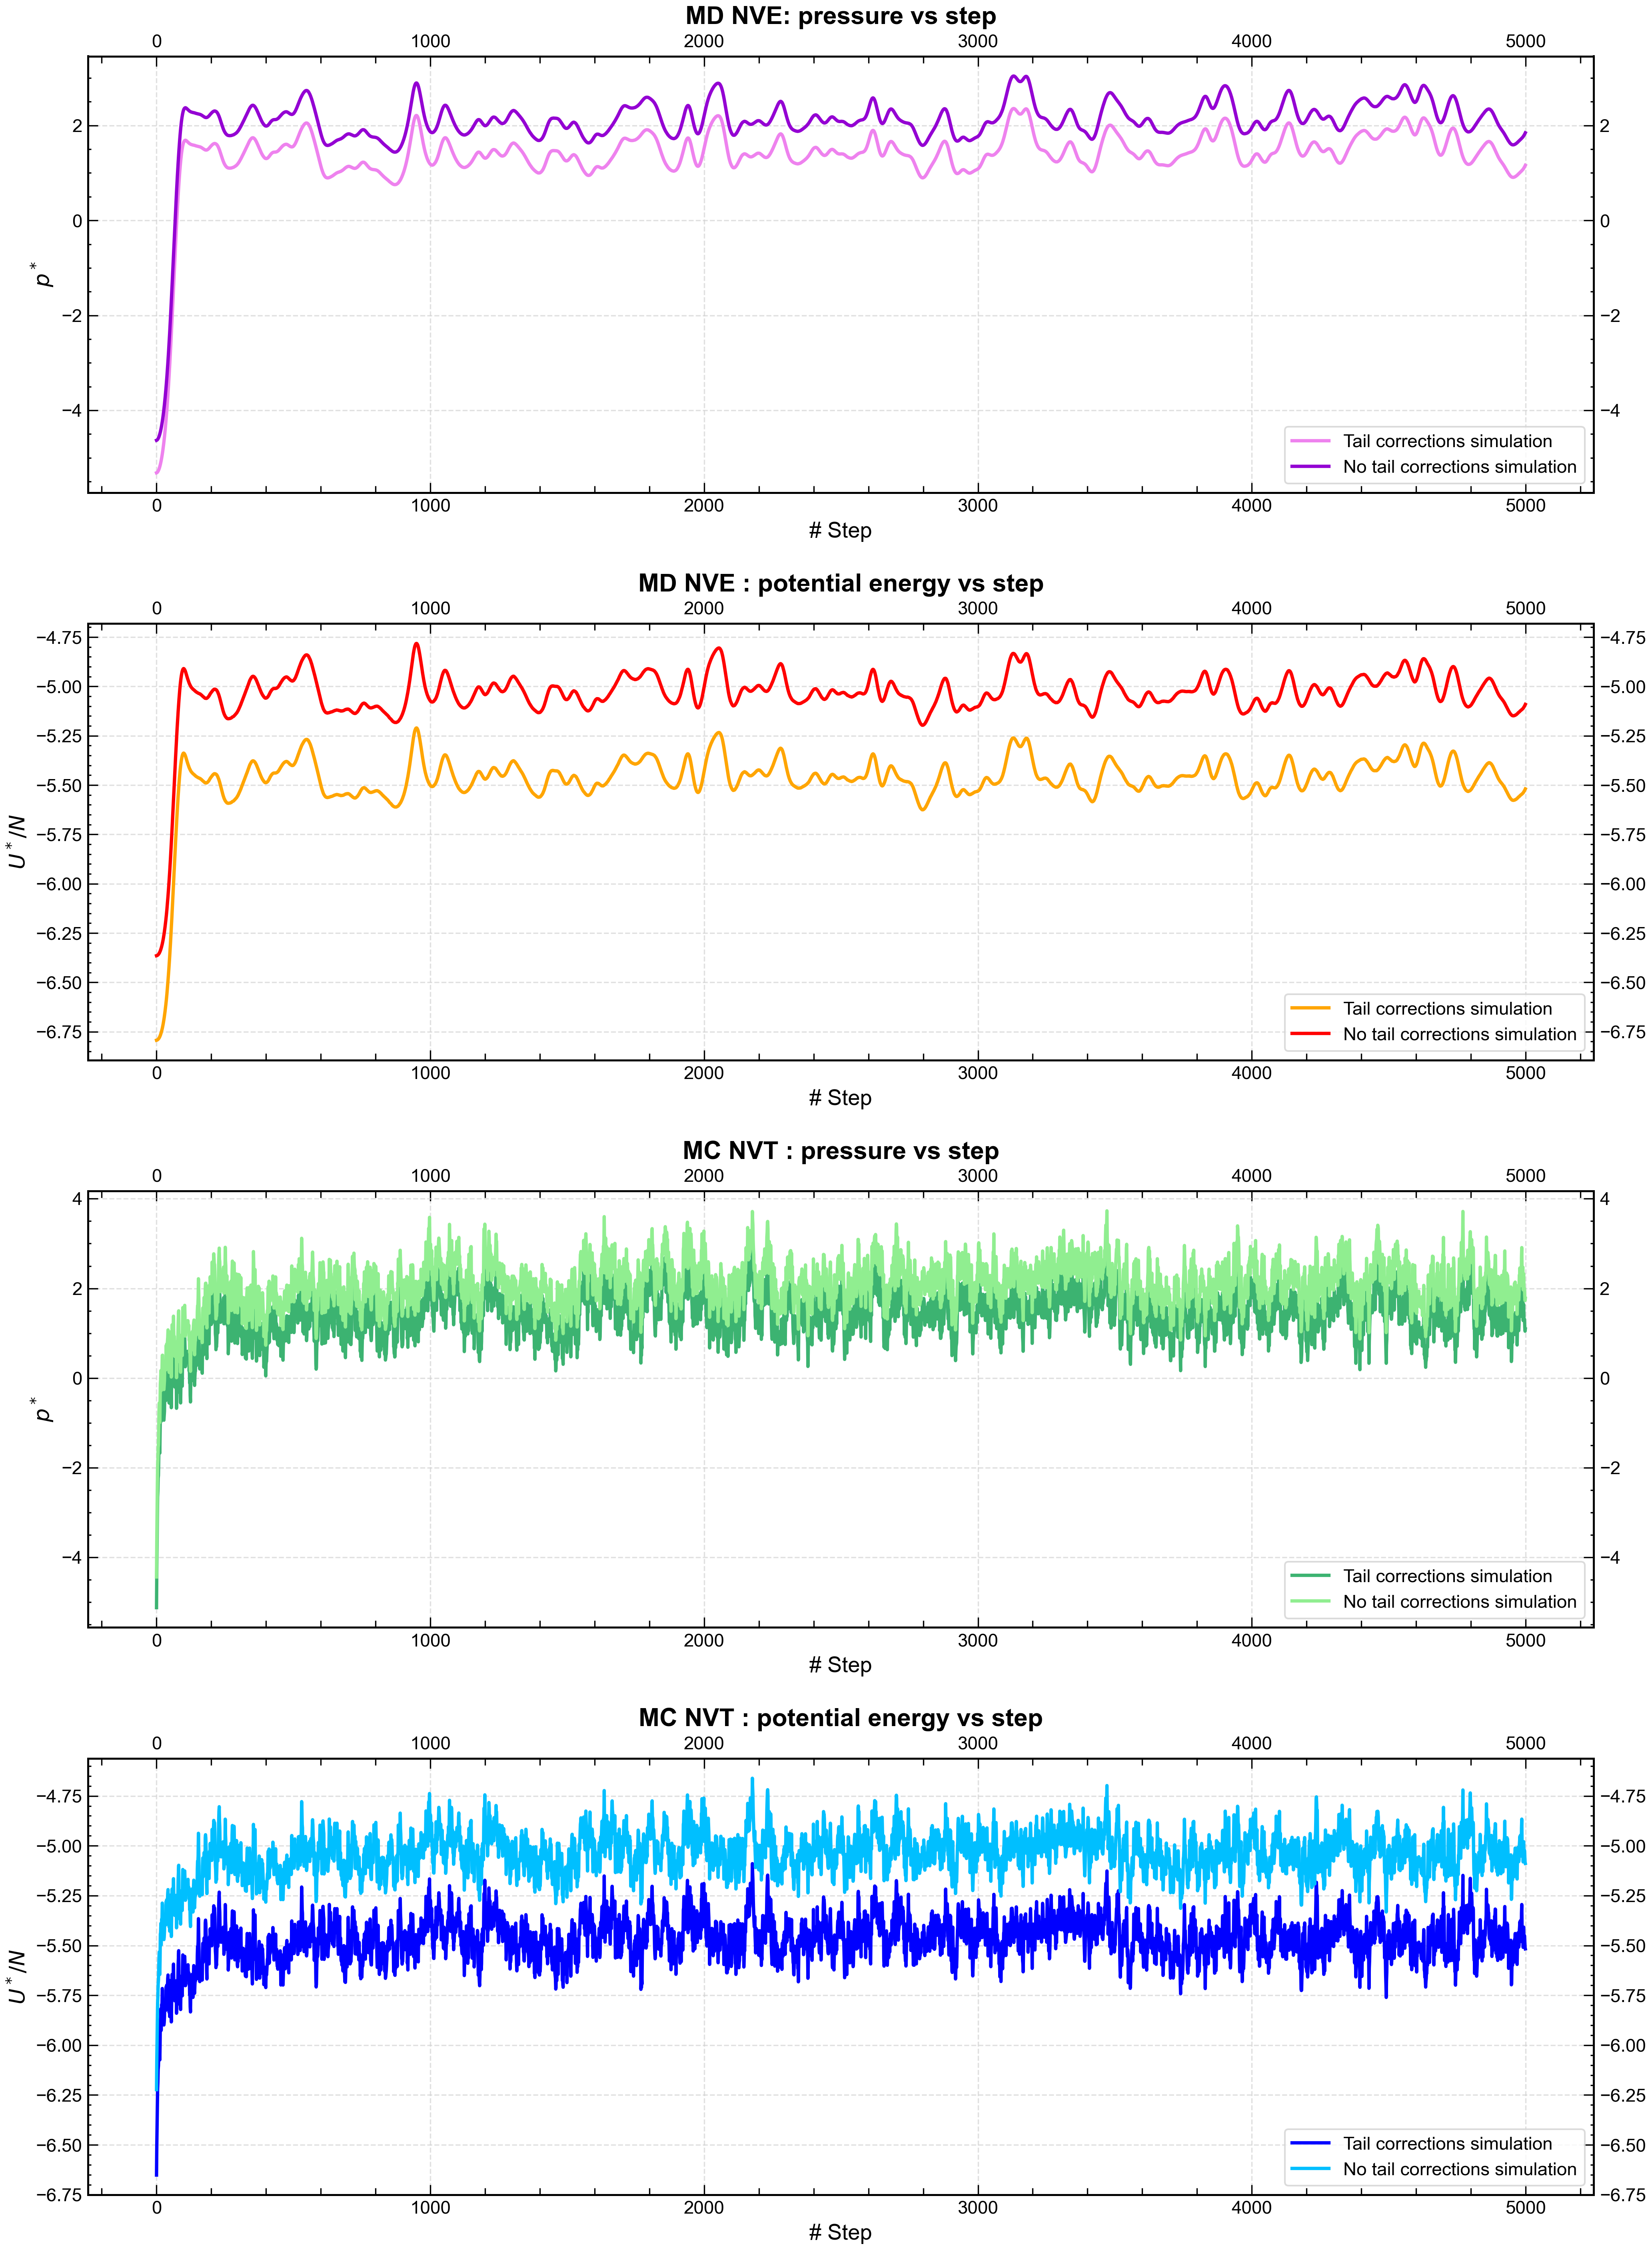

In [57]:
x = np.arange(0, equil_step)

dir_path_on = ["MD_NVE/liquid/tail_corrections/on/OUTPUT/", "MC_NVT/liquid/tail_corrections/on/OUTPUT/"]
dir_path_off = ["MD_NVE/liquid/tail_corrections/off/OUTPUT/", "MC_NVT/liquid/tail_corrections/off/OUTPUT/"]
title = ["MD_NVE :", "MC_NVT :"]

fig, axs = plt.subplots(4, 1, figsize=(14, 20))

pressure_on = np.loadtxt("MD_NVE/liquid/tail_corrections/on/OUTPUT/pressure.dat", usecols=(1), unpack=True)
pressure_off = np.loadtxt("MD_NVE/liquid/tail_corrections/off/OUTPUT/pressure.dat", usecols=(1), unpack=True)

axs[0].set_title("MD NVE: pressure vs step")
axs[0].plot(x, pressure_on, color="violet", label="Tail corrections simulation")
axs[0].plot(x, pressure_off, color="darkviolet", label="No tail corrections simulation")
axs[0].set_xlabel("# Step")
axs[0].set_ylabel(r"$p^*$")
axs[0].legend()

potential_on = np.loadtxt("MD_NVE/liquid/tail_corrections/on/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)
potential_off = np.loadtxt("MD_NVE/liquid/tail_corrections/off/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)

axs[1].set_title("MD NVE : potential energy vs step")
axs[1].plot(x, potential_on, color="orange",label="Tail corrections simulation")
axs[1].plot(x, potential_off, color="red", label="No tail corrections simulation")
axs[1].set_xlabel("# Step")
axs[1].set_ylabel(r"$U^*/N$")
axs[1].legend()

pressure_on = np.loadtxt("MC_NVT/liquid/tail_corrections/on/OUTPUT/pressure.dat", usecols=(1), unpack=True)
pressure_off = np.loadtxt("MC_NVT/liquid/tail_corrections/off/OUTPUT/pressure.dat", usecols=(1), unpack=True)

axs[2].set_title("MC NVT : pressure vs step")
axs[2].plot(x, pressure_on, color="mediumseagreen", label="Tail corrections simulation")
axs[2].plot(x, pressure_off, color="lightgreen", label="No tail corrections simulation")
axs[2].set_xlabel("# Step")
axs[2].set_ylabel(r"$p^*$")
axs[2].legend()

potential_on = np.loadtxt("MC_NVT/liquid/tail_corrections/on/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)
potential_off = np.loadtxt("MC_NVT/liquid/tail_corrections/off/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)

axs[3].set_title("MC NVT : potential energy vs step")
axs[3].plot(x, potential_on, color="blue",label="Tail corrections simulation")
axs[3].plot(x, potential_off, color="deepskyblue", label="No tail corrections simulation")
axs[3].set_xlabel("# Step")
axs[3].set_ylabel(r"$U^*/N$")
axs[3].legend()

fig.tight_layout()
fig.subplots_adjust(
    wspace=0.3,  # Spazio orizzontale
    hspace=0.3, # Spazio verticale
    top=0.92     # move below plots (gives space to suptitle)
)

fig.savefig("plot/liquid/tail_corrections/tail_corrections.png")

plt.show()




<h4>Conclusions</h4>

The observed results are in complete agreement with the theoretical expectations for a system governed by an attractive long-range potential, such as Lennard-Jones.

- **Potential Energy** ($U^*/N$): By incorporating the tail correction, the potential energy per particle **increases in magnitude**, becoming more negative. The tail correction accounts for the **unsimulated attractive energy** between particles separated by distances $r > r_{cut}$. Since the Lennard-Jones potential is negative (attractive) beyond $r \approx 1.12\sigma$, the term $\langle \mathcal{V} \rangle_{\text{tail}}$ is negative. Adding this negative contribution to the truncated potential $\langle \mathcal{V} \rangle_{\text{cut}}$ shifts the total energy ($\langle \mathcal{V} \rangle_{\text{total}}$) downwards, making it more stable and negative.

- **Pressure** ($p^*$): The pressure undergoes a **negative correction** (a decrease in value). The pressure is calculated using the Virial theorem, which includes the contribution of the inter-particle forces. When the attractive tail force (which is an **inward-pulling** force) is incorporated, the total net force on the particles, and consequently the pressure, decreases. **The pressure measured in the truncated simulation is an *overestimation*** because it fails to account for the attractive forces that would otherwise reduce the frequency and intensity of collisions against the container walls. By adding the constant, negative pressure tail correction, the total pressure is corrected to its true, lower thermodynamic value.

<h3><span style="color:darkviolet">Equilibration</span></h3>

Equilibration is a crucial, foundational step required for any simulation, whether it is **MD** or **MCMC**.

**Microcanonical Ensemble**:

As previously established, the microcanonical NVE ensemble models an isolated system where the total energy is conserved. While the total energy remains constant, its individual components—kinetic energy and potential energy—are expected to fluctuate.

The simulation is initialized in an ordered configuration (**Face-Centered Cubic (FCC) lattice**) which is characteristic of a solid state. To simulate a fluid, the system must transition through a "melting" phase, where particles detach from the crystalline structure to achieve a disordered configuration characteristic of a liquid.

To monitor the NVE equilibration process, we observe the **temperature** as a function of time. After an initial transient period, the system's temperature thermalizes to a lower value than the initial temperature.

Since our objective is to simulate a liquid system at the target equilibrium temperature $T_{eq}^* = 1.1$, various initial temperatures are tested to ensure that the final steady-state average temperature of the simulation precisely matches the target temperature. Through this iterative process, the ideal starting temperature required to reach $T_{eq}^* = 1.1$ has been determined to be $T^* = 1.972$.

**Canonical Ensemble**:

The canonical NVT ensemble is simulated by sampling the configurational Boltzmann weight using MCMC methods. The Metropolis algorithm, in particular, only converges asymptotically to the desired stationary distribution. Therefore, an equilibration phase is necessary to ensure the algorithm reaches a statistically representative configuration before sampling begins.

A critical aspect for NVT simulations is the acceptance ratio. Standard practice dictates that this ratio should be around $50\%$ for optimal computational efficiency. The acceptance ratio in the Metropolis algorithm is controlled by the step size of the trial move, defined by the input variable `DELTA`. After optimization, a step size of $0.1005$ was found to achieve the desired $50\%$ acceptance rate.

**NB**: Equilibration is a mandatory step for every simulation as it ensures the initial system configuration is fully relaxed to a state consistent with the target thermodynamic ensemble. This prevents any systematic bias from affecting the measurement of the physical quantities of interest. 

The NVE and NVT system equilibrations were conducted using the following input parameters:

<div align="center">

| Parameters | NVE equilibration | NVT equilibration |
| :--- | :--- | :--- |
| SIMULATION_TYPE | 0 | 1 |
| DISTRIBUTION_TYPE | 0 | - |
| RESTART | 0 | 0 |
| TEMP | 1.972 | 1.1 |
| NPART | 108 | 108 |
| RHO | 0.8 | 0.8 |
| R_CUT | 2.5 | 2.5 |
| DELTA | 0.001 | 0.1005 |
| NBLOCKS | 5000 | 5000 |
| NSTEPS | 1 | 1 |
| TAILS | 1 | 1 |

</div>

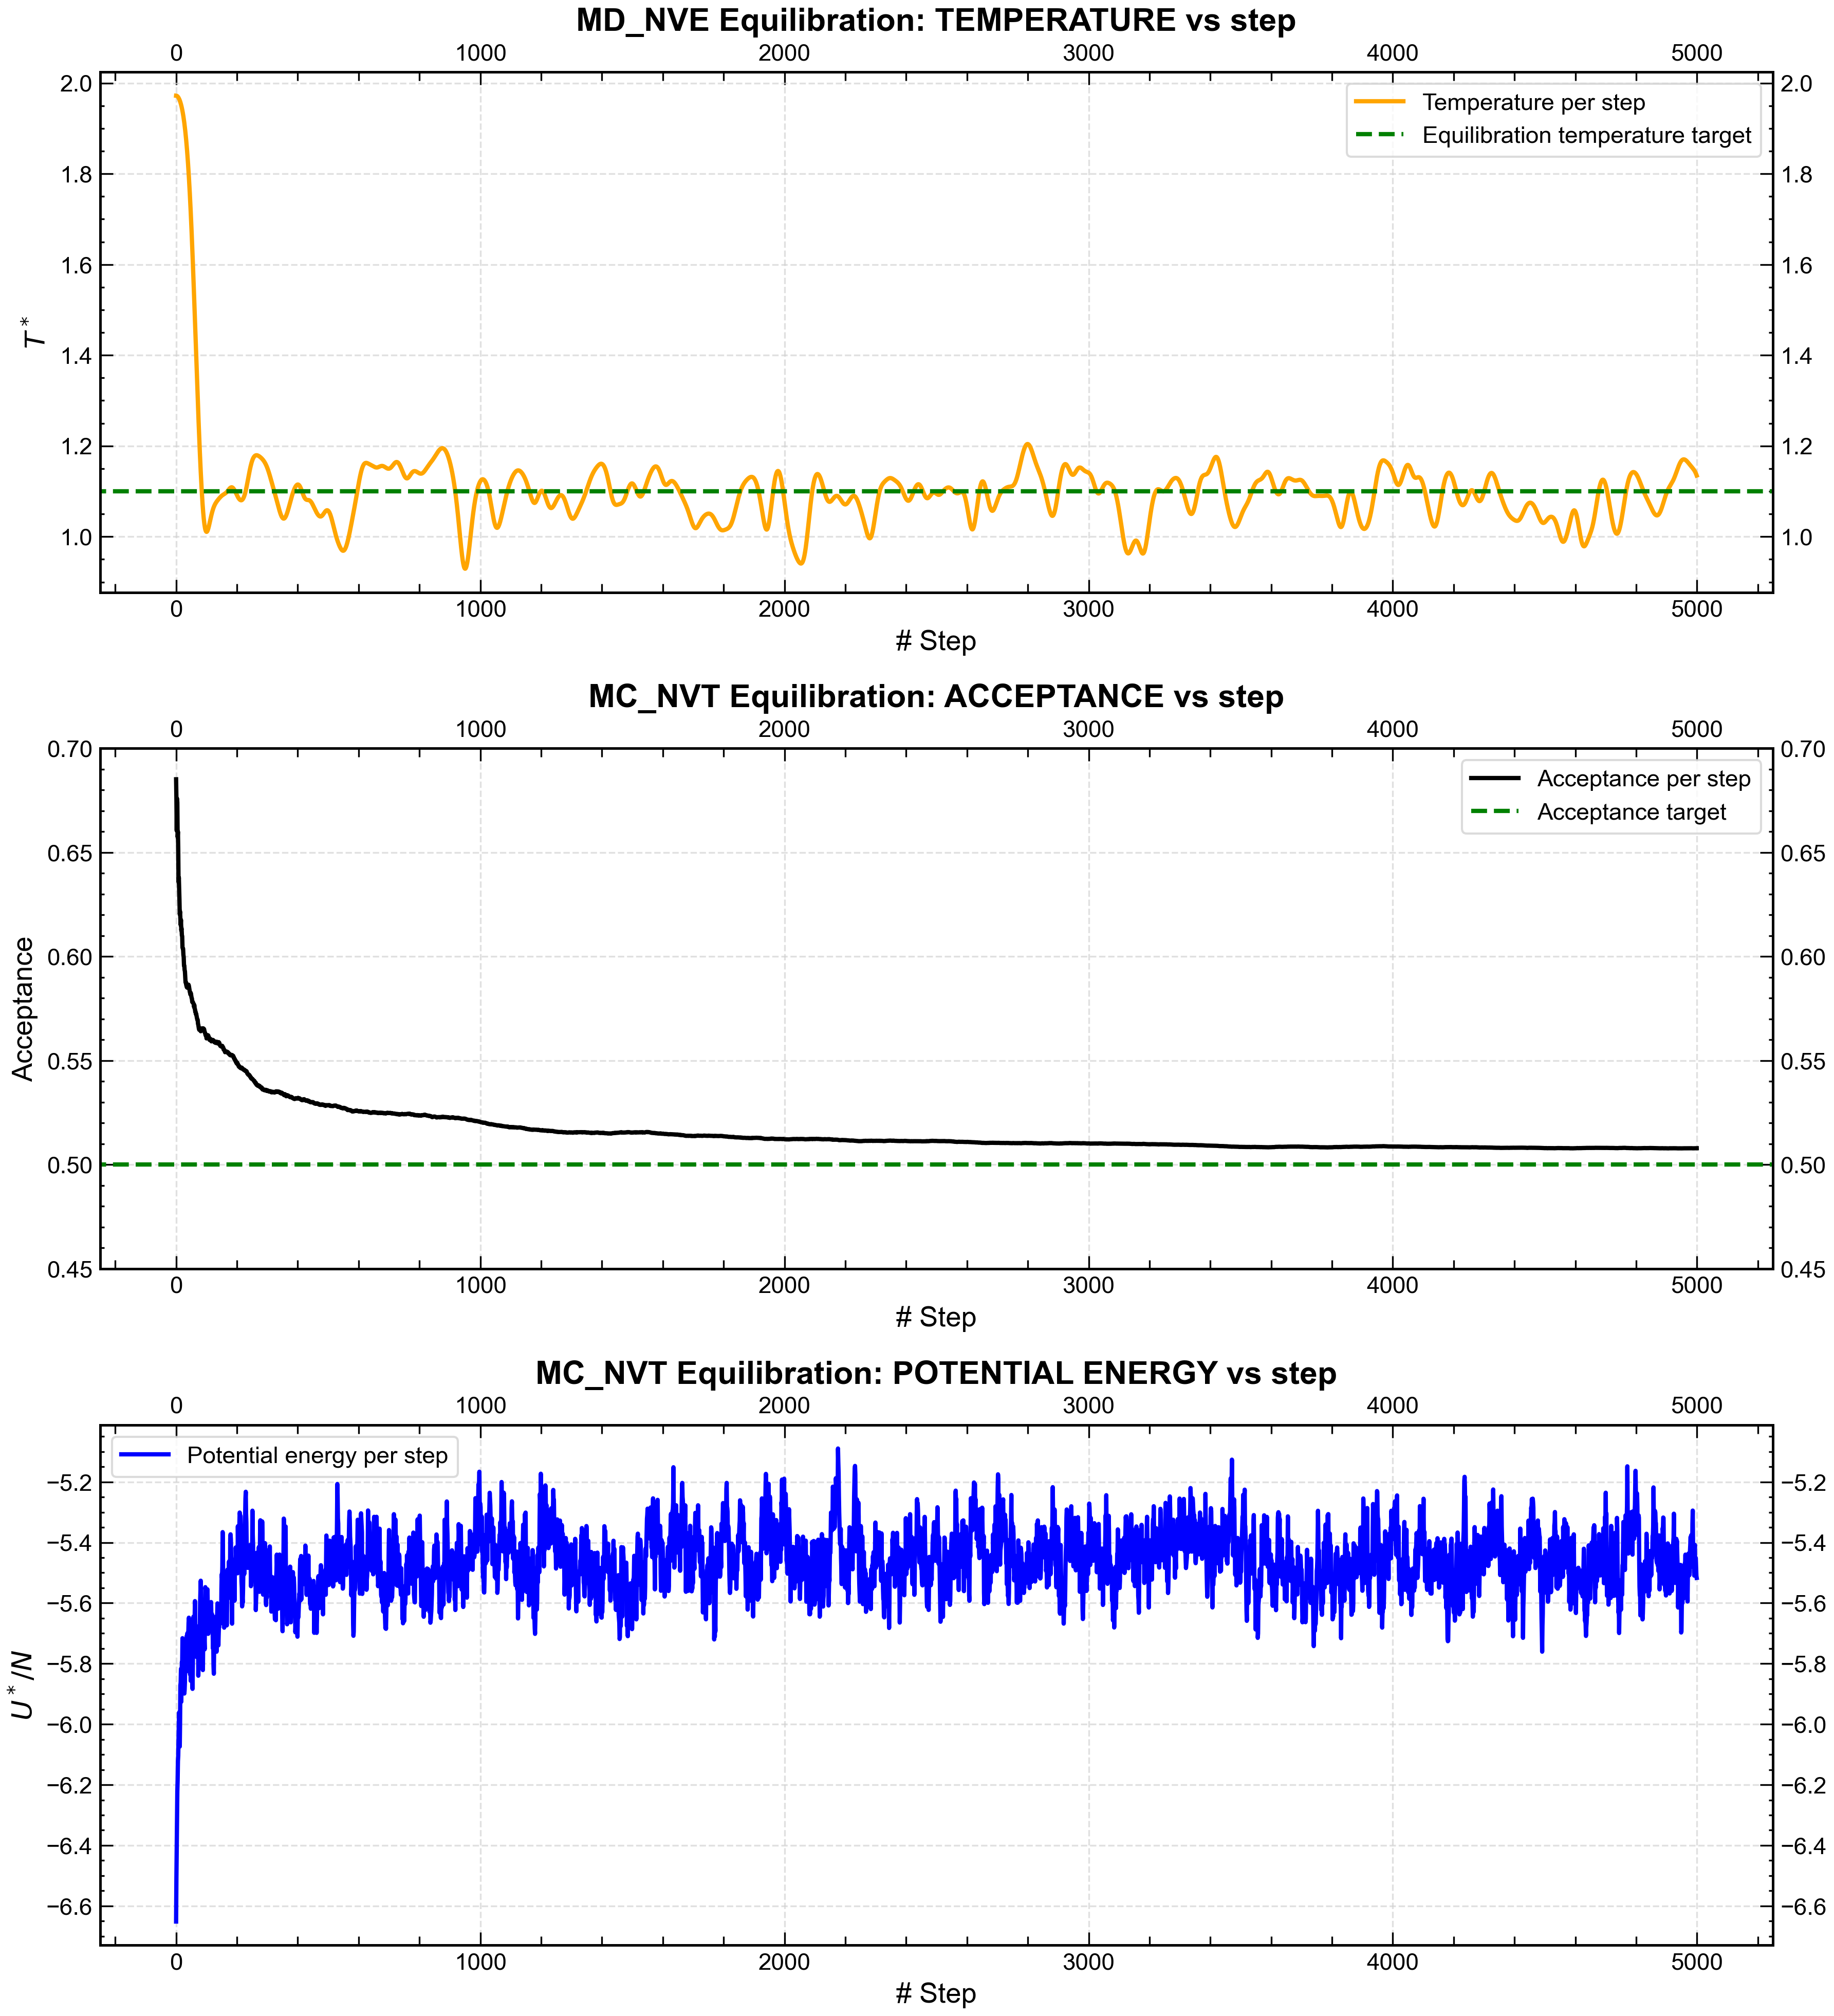

In [58]:
temp = np.loadtxt("MD_NVE/liquid/equilibration/OUTPUT/temperature.dat", usecols=(1), unpack=True)
accept = np.loadtxt("MC_NVT/liquid/equilibration/OUTPUT/acceptance.dat", usecols=(1), unpack=True)
poten_en = np.loadtxt("MC_NVT/liquid/equilibration/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)
x = np.arange(0, equil_step)

fig, axs = plt.subplots(3,1, figsize=(14,15))

axs[0].set_title("MD_NVE Equilibration: TEMPERATURE vs step")
axs[0].set_xlabel("# Step")
axs[0].set_ylabel(r"$T^*$")
axs[0].plot(x, temp, color="orange", label="Temperature per step")
axs[0].axhline(1.1, -10, x[-1]+10, color="green", linestyle="--", label="Equilibration temperature target")
axs[0].legend()

axs[1].set_title("MC_NVT Equilibration: ACCEPTANCE vs step")
axs[1].set_xlabel("# Step")
axs[1].set_ylabel("Acceptance")
axs[1].plot(x, accept, color="black", label="Acceptance per step")
axs[1].axhline(0.5, -10, x[-1]+10, color="green", linestyle="--", label="Acceptance target")
axs[1].set_ylim(0.45, 0.7)
axs[1].legend()

axs[2].set_title("MC_NVT Equilibration: POTENTIAL ENERGY vs step")
axs[2].set_xlabel("# Step")
axs[2].set_ylabel(r"$U^*/N$")
axs[2].plot(x, poten_en, color="blue", label="Potential energy per step")
axs[2].legend()

fig.subplots_adjust(
        wspace=0.3,  # Spazio orizzontale
        hspace=0.3, # Spazio verticale
        top=0.92     # move below plots (gives space to suptitle)
)
fig.savefig("plot/liquid/equilibration/equilibration.png")

plt.show()


<a id="autocorr-func"></a>

<h3><span style="color:darkviolet">Autocorrelation</span></h3>

Studiare la funzione di autocorrelazione è fondamentale per simulazioni di MD e MCMC in quanto ci permette di capire quanto un determinato processo sia correlato a se stesso nel tempo. Questo permette di capire come gestire l'analisi dei dati per stimare in modo corretto le incertezze statistiche (vogliamo usare il teorema del limite centrale che vale per variabili stocastiche statisticamente indipendenti), necessarie per trarre conclusioni quando si simulano sistemi con metodi Monte Carlo.

Dato un processo stocastico stazionario $X(t)$, la funzione di autocorrelazione per ogni dato **lag temporale** $\tau$ è definita nel seguente modo:

$$ACF_{[X]}(\tau) = \frac{cov_{[X,X]}(t, t + \tau)}{\sqrt{cov_{[X,X]}(t,t)}\sqrt{cov_{[X,X]}(t+\tau,t+\tau)}} = \frac{\langle X(t)X(t+\tau) \rangle - \langle X(t) \rangle \langle X(t+\tau) \rangle}{\sigma^2_X},$$

dove abbiamo sfruttato che la correlazione di un processo stocastico con se stesso allo stesso tempo è la varianza e il fatto che per un processo stocastico stazionario la varianza è costante nel tempo.

Dalla funzione di autocorrelazione possiamo determinare quantitativamente per quanto tempo un determinato sistema conserva memoria della sua storia passata. Infatti si ha che:

- Se la funzione di autocorrelazione è nulla per ogni lag temporale allora il processo stocastico non ha memoria del passato.

- Se la funzione di autocorrelazione diventa nulla oltre ad un determinato lag temporare $\tau_c > 0$ allora il processo stocastico perde memoria del passato dopo un determinato intevallo di tempo. Questo definisce un tempo scala caratteristico di memoria.

In seguito alla fase di equilibrazione sono state condotte due simulazioni distinte per i due sistemi (NVE ed NVT) in cui sono stati prodotti $500000$ valori di energia potenziale per particella. Nel nostro caso abbiamo una serie temporale discreta di misure di energia potenziale $ \{ X(0), X(t_1), X(t_2), \ldots, X(t_{max}) \} $ effettuate in un intervallo di tempo finito $[0, t_{max}]$ ad una distanza temporare fissata $\Delta t = t_{i+1} - t_{i} ~~,~~ \forall ~ i = 0, \ldots N-1$.

Esistono due maniere diverse di calcolarsi la funzione di autocorrelazione per serie temporali discrete, che vengono rispettivamente dette **unbiased** e **biased**. 

In quelle unbiased la funzione di autocovarianza (al numeratore) è normalizzata con un denominatore la cui taglia cambia in funzione del lag temporale. Esse sono statisticamente corrette, in quanto stimano in maniera corretta la funzione di autocorrelazione, ma hanno il problema che sono computazionalmente inefficienti per lunghe serie temporali ed inoltre non sono stabili. All'aumentare del lag temporale la coviarianza viene calcolata su campioni sempre più piccoli ed inoltre la dimensione dell'intervallo cala. In questo modo viene dato molto più peso agli ultimi valori della serie temporale e la funzione di autocorrelazione è instabile ed "esplode" a lag temporali grandi. Esistono dei metodi di finestraggio, come quello di Barlett, che vengono utilizzati per rendere il metodo più stabile andando a pesare la funzione di autocorrelazione per un fattore, detto fattore di Barlett, che abbatte la funzione di autocorrelazione a grandi lag temporali.

$$
ACF_{~U}^{~unbias}(\tau) 
=
\frac{
  \displaystyle
    \frac{1}{t_{max} - \tau}
    \sum_{t^{\prime}}^{t_{max} - \tau}U(t^{\prime})U(t^{\prime}+\tau)
  \;-\;
  \Bigl(\frac{1}{t_{max} - \tau}\sum_{t^{\prime}}^{t_{max} - \tau}U(t^{\prime})\Bigr)
  \Bigl(\frac{1}{t_{max} - \tau}\sum_{t^{\prime}}^{t_{max} - \tau}U(t^{\prime}+\tau)\Bigr)
}{
  \displaystyle
    \frac{1}{t_{max}}
    \sum_{t^{\prime}=0}^{t_{max}}U^2(t^{\prime})
  \;-\;
  \Bigl(\frac{1}{t_{max}}\sum_{t^{\prime}=0}^{t_{max}}U(t^{\prime})\Bigr)^{2}
}
.$$

Il fattore di Barlett è definito nel seguente modo:

$$
W(\tau) =
\begin{cases}
1 - \frac{\tau}{\tau_{max}} \text{ if } \tau \le \tau_{max} \\
0 \text{ if } \tau > \tau_{max}
\end{cases}
,$$

in modo che la funzione di autocorrelazione sia pesata di meno per grandi lag temporali, oltre ad un certo lag massimo che solitamente viene fissato a 10 volte il tempo di correlazione.

Quelle biased invece vanno a demediare ogni singola variabile e calcolano la funzione di autocorrelazione come il rapporto tra l'autocovarianza demediata al lag $\tau$ divisa l'autocovarianza dememdiata al lag 0.

Si definisce funzione di autocovarianza al lag $\tau$ al funzione:

$$\gamma_{X}(\tau) = \frac{1}{t_{max}} \sum_{t^{\prime} = 0}^{t_{max}}$$

In [59]:
def barlett_window(tau, t_max = 1000):
    if(tau > t_max):
        return 0.0
    return 1 - (tau/t_max)

def biased_acf(quantity, var):
    
    t_max = len(quantity)
    acorr = np.zeros(t_max)

    for t in range(t_max):

        delta_t = t_max - t
        norm = 1.0 / t_max
        xy = 0.0

        for t_prime in range(delta_t):
            xy += quantity[t_prime] * quantity[t_prime + t]
        
        num = norm * xy
        acorr[t] = (num / var) 

    return acorr

def unbiased_acf(quantity, var):
    
    t_max = len(quantity)
    acorr = np.zeros(t_max)

    for t in range(t_max):

        delta_t = t_max - t
        norm_num = 1.0 / delta_t
        x = 0.0
        y = 0.0
        xy = 0.0

        for t_prime in range(delta_t):

            x += quantity[t_prime]
            y += quantity[t_prime + t]
            xy += quantity[t_prime] * quantity[t_prime + t]

        
        num = norm_num * xy - (norm_num * x) * (norm_num * y)
        acorr[t] = num / var

    return acorr

In [60]:
potential_NVE = np.loadtxt("MD_NVE/liquid/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)[:acf_step]
potential_NVT = np.loadtxt("MC_NVT/liquid/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)[:acf_step]

var_NVE = np.var(potential_NVE)
var_NVT = np.var(potential_NVT)

unbiased_acf_NVE = unbiased_acf(potential_NVE, var_NVE)
unbiased_acf_NVT = unbiased_acf(potential_NVT, var_NVT)

In [61]:
unbiased_acf_NVE_barlett = unbiased_acf_NVE * [barlett_window(t, t_max=10000) for t in range(acf_step)]
unbiased_acf_NVT_barlett = unbiased_acf_NVT * [barlett_window(t, t_max=10000) for t in range(acf_step)]

In [62]:
# Calcolo della media campionaria
mean_NVE = np.mean(potential_NVE)
mean_NVT = np.mean(potential_NVT)

# Demediazione per utilizzare formula del libro
potential_NVE = potential_NVE - mean_NVE
potential_NVT = potential_NVT - mean_NVT

# Calcolo della varianza per evitare calcoli superflui nella funzione di autocorrelazione
var_NVE = np.var(potential_NVE)
var_NVT = np.var(potential_NVT)

biased_acf_NVE = biased_acf(potential_NVE, var_NVE)
biased_acf_NVT = biased_acf(potential_NVT, var_NVT)

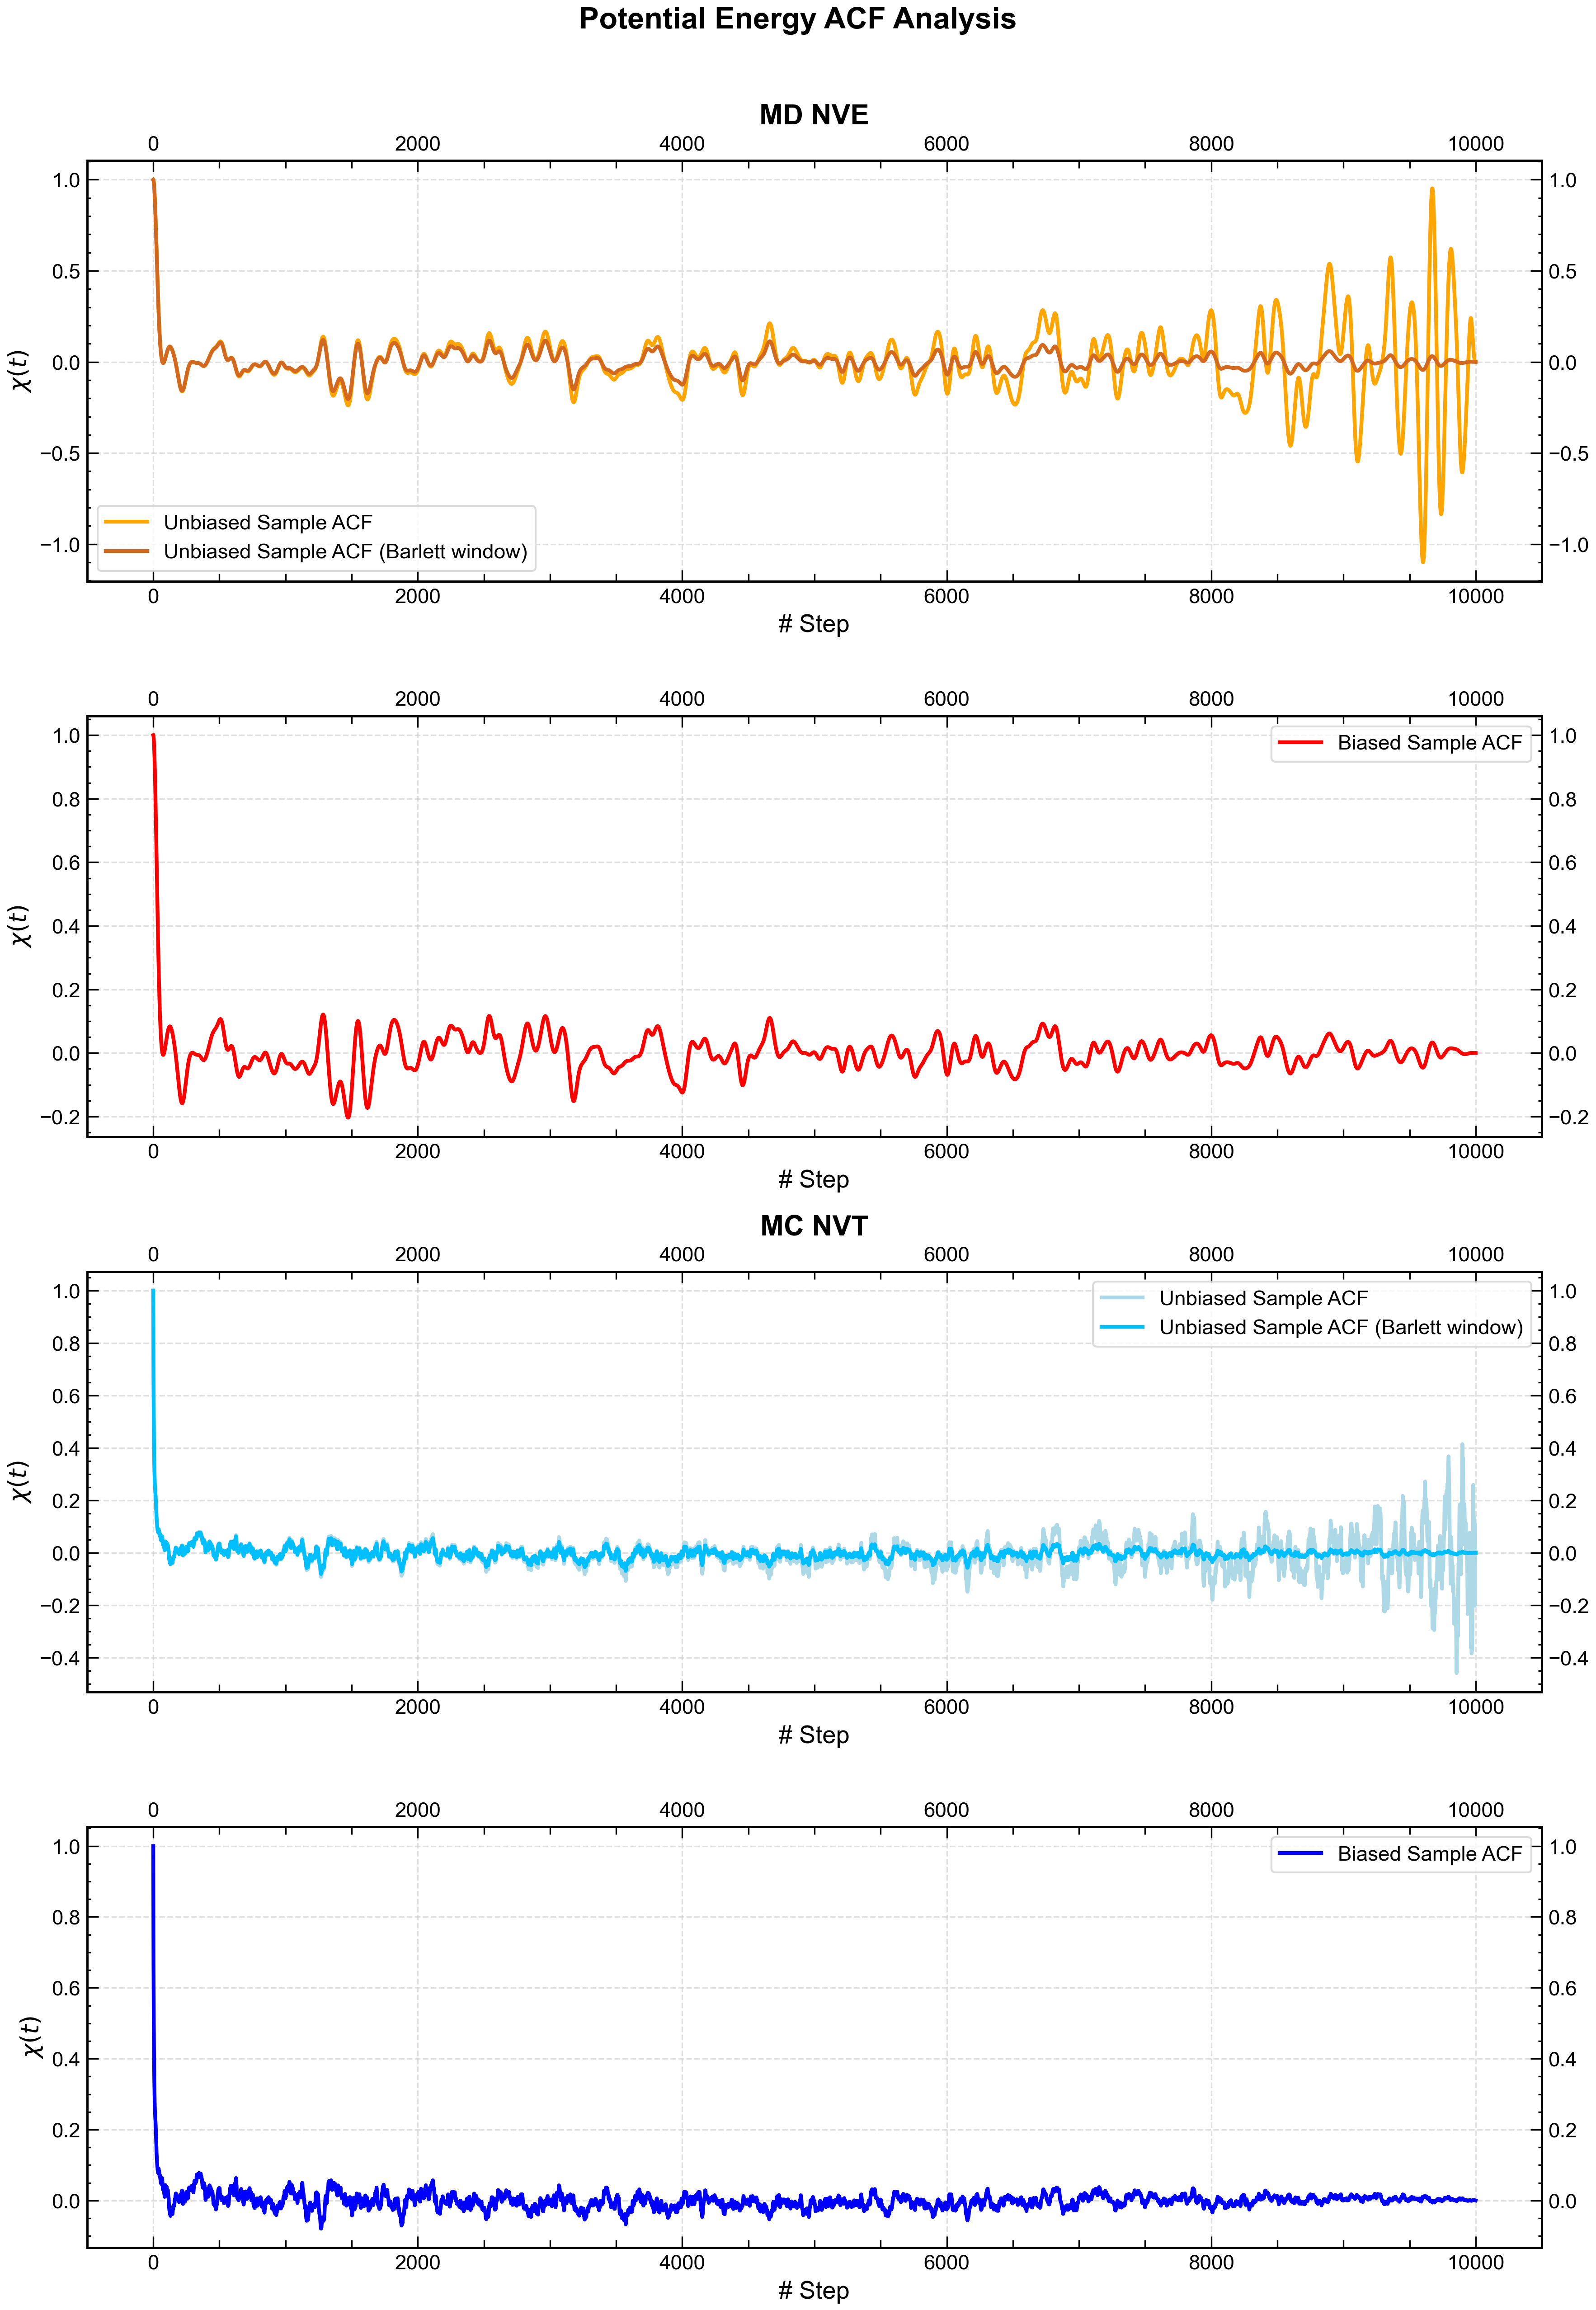

In [68]:
# Assumo che acf_step, unbiased_acf_NVE, ecc. siano stati definiti
x = np.arange(0, acf_step) 

fig, axs = plt.subplots(4, 1, figsize=(12, 18)) 

fig.suptitle("Potential Energy ACF Analysis", fontweight="bold", fontsize=16)

axs[0].set_title("MD NVE")
axs[0].plot(x, unbiased_acf_NVE, color="orange", label="Unbiased Sample ACF")
axs[0].plot(x, unbiased_acf_NVE_barlett, color="chocolate", label="Unbiased Sample ACF (Barlett window)")
axs[0].set_xlabel("# Step")
axs[0].set_ylabel(r"$\chi(t)$")
axs[0].legend()

axs[1].plot(x, biased_acf_NVE, color="red", label="Biased Sample ACF")
axs[1].set_xlabel("# Step")
axs[1].set_ylabel(r"$\chi(t)$")
axs[1].legend()

axs[2].set_title("MC NVT")
axs[2].plot(x, unbiased_acf_NVT, color="lightblue", label="Unbiased Sample ACF")
axs[2].plot(x, unbiased_acf_NVT_barlett, color="deepskyblue", label="Unbiased Sample ACF (Barlett window)")
axs[2].set_xlabel("# Step")
axs[2].set_ylabel(r"$\chi(t)$")
axs[2].legend()

axs[3].plot(x, biased_acf_NVT, color="blue", label="Biased Sample ACF")
axs[3].set_xlabel("# Step")
axs[3].set_ylabel(r"$\chi(t)$")
axs[3].legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])

fig.savefig("plot/liquid/autocorrelation/autocorrelation_pot_energy.png")
plt.show()

<a id="data-blocking-error"></a>

<h3><span style="color:darkviolet">Data Blocking</span></h3>

In [64]:
def error(A_sum: float, A_sq_sum: float, i: int) -> float:
    
    # N_samp is the number of samples (blocks) calculated so far
    N_samp = i + 1 
    
    # If we have less than 2 samples, we cannot calculate the variance (ddof=1)
    if N_samp < 2:
        return 0.0
    
    # Calculate the cumulative mean of the squared block means (S2 / N_samp)
    A_sq_mean = A_sq_sum / N_samp
    # Calculate the cumulative mean of the block means (S1 / N_samp)
    A_mean = A_sum / N_samp

    # Calculate the variance numerator: E[A^2] - (E[A])^2
    num = A_sq_mean - A_mean**2

    # Calculate the Standard Deviation of the block means
    err = np.sqrt(num/(N_samp - 1))
    
    return err


def data_blocking(obs: np.ndarray, L: int) -> float:    # Calculates the final progressive error for a specific block length L
    
    M = len(obs)    # Total dataset size
    if L <= 0:
        return np.nan

    # Calculate N (number of blocks) using integer division (//)
    N = M // L
    
    if N < 2:
        # Cannot calculate variance with less than 2 blocks.
        return np.nan 
    
    # Determine the effective length of the data to be used (exact multiple of L)
    L_eff = N * L
    
    # Vectorized Calculation of Block Means (A_i)
    # 1. Truncation: obs[:L_eff] selects the data divisible by L
    # 2. Reshape: .reshape(N, L) creates a matrix where each row is a block 
    # 3. Mean: .mean(axis=1) calculates the mean for each row (single block mean A_i)
    block_means = obs[:L_eff].reshape(N, L).mean(axis=1)
    
    A_sum = 0.0      # Accumulator variable: Cumulative sum of block means (S1)
    A_sq_sum = 0.0   # Accumulator variable: Cumulative sum of squared block means (S2)
    
    last_error = 0.0 # Variable to store the error calculated on the last block

    # Loop over the N block means to calculate the progressive error
    for i in range(N):
        A_k = block_means[i]  # Current block mean (A_i)
        
        # Update the cumulative sum of means
        A_sum += A_k
        # Update the cumulative sum of squared means
        A_sq_sum += A_k * A_k
        
        # The final error (err[-1]) is calculated and saved only on the last iteration (i = N-1)
        if(i==N-1):
            last_error = error(A_sum, A_sq_sum, i)

    return last_error

In [65]:
# Dataset loading
potential_NVE = np.loadtxt("MD_NVE/liquid/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)
potential_NVT = np.loadtxt("MC_NVT/liquid/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)

# Minimum block size
L_min = 10
# Maximum block size
L_max = 5000
# Array of tested block sizes
L_values = np.arange(L_min, L_max + 1)
# Number of block sizes attempted
num_L = len(L_values)
# Arrays for calculated errors corresponding to successive block sizes
err_NVE = np.zeros(num_L)
err_NVT = np.zeros(num_L)

# Loop over the tested block sizes and fill the respective error arrays
for i in range(num_L):
    L = L_values[i]
    err_NVE[i] = data_blocking(potential_NVE, L)
    err_NVT[i] = data_blocking(potential_NVT, L)

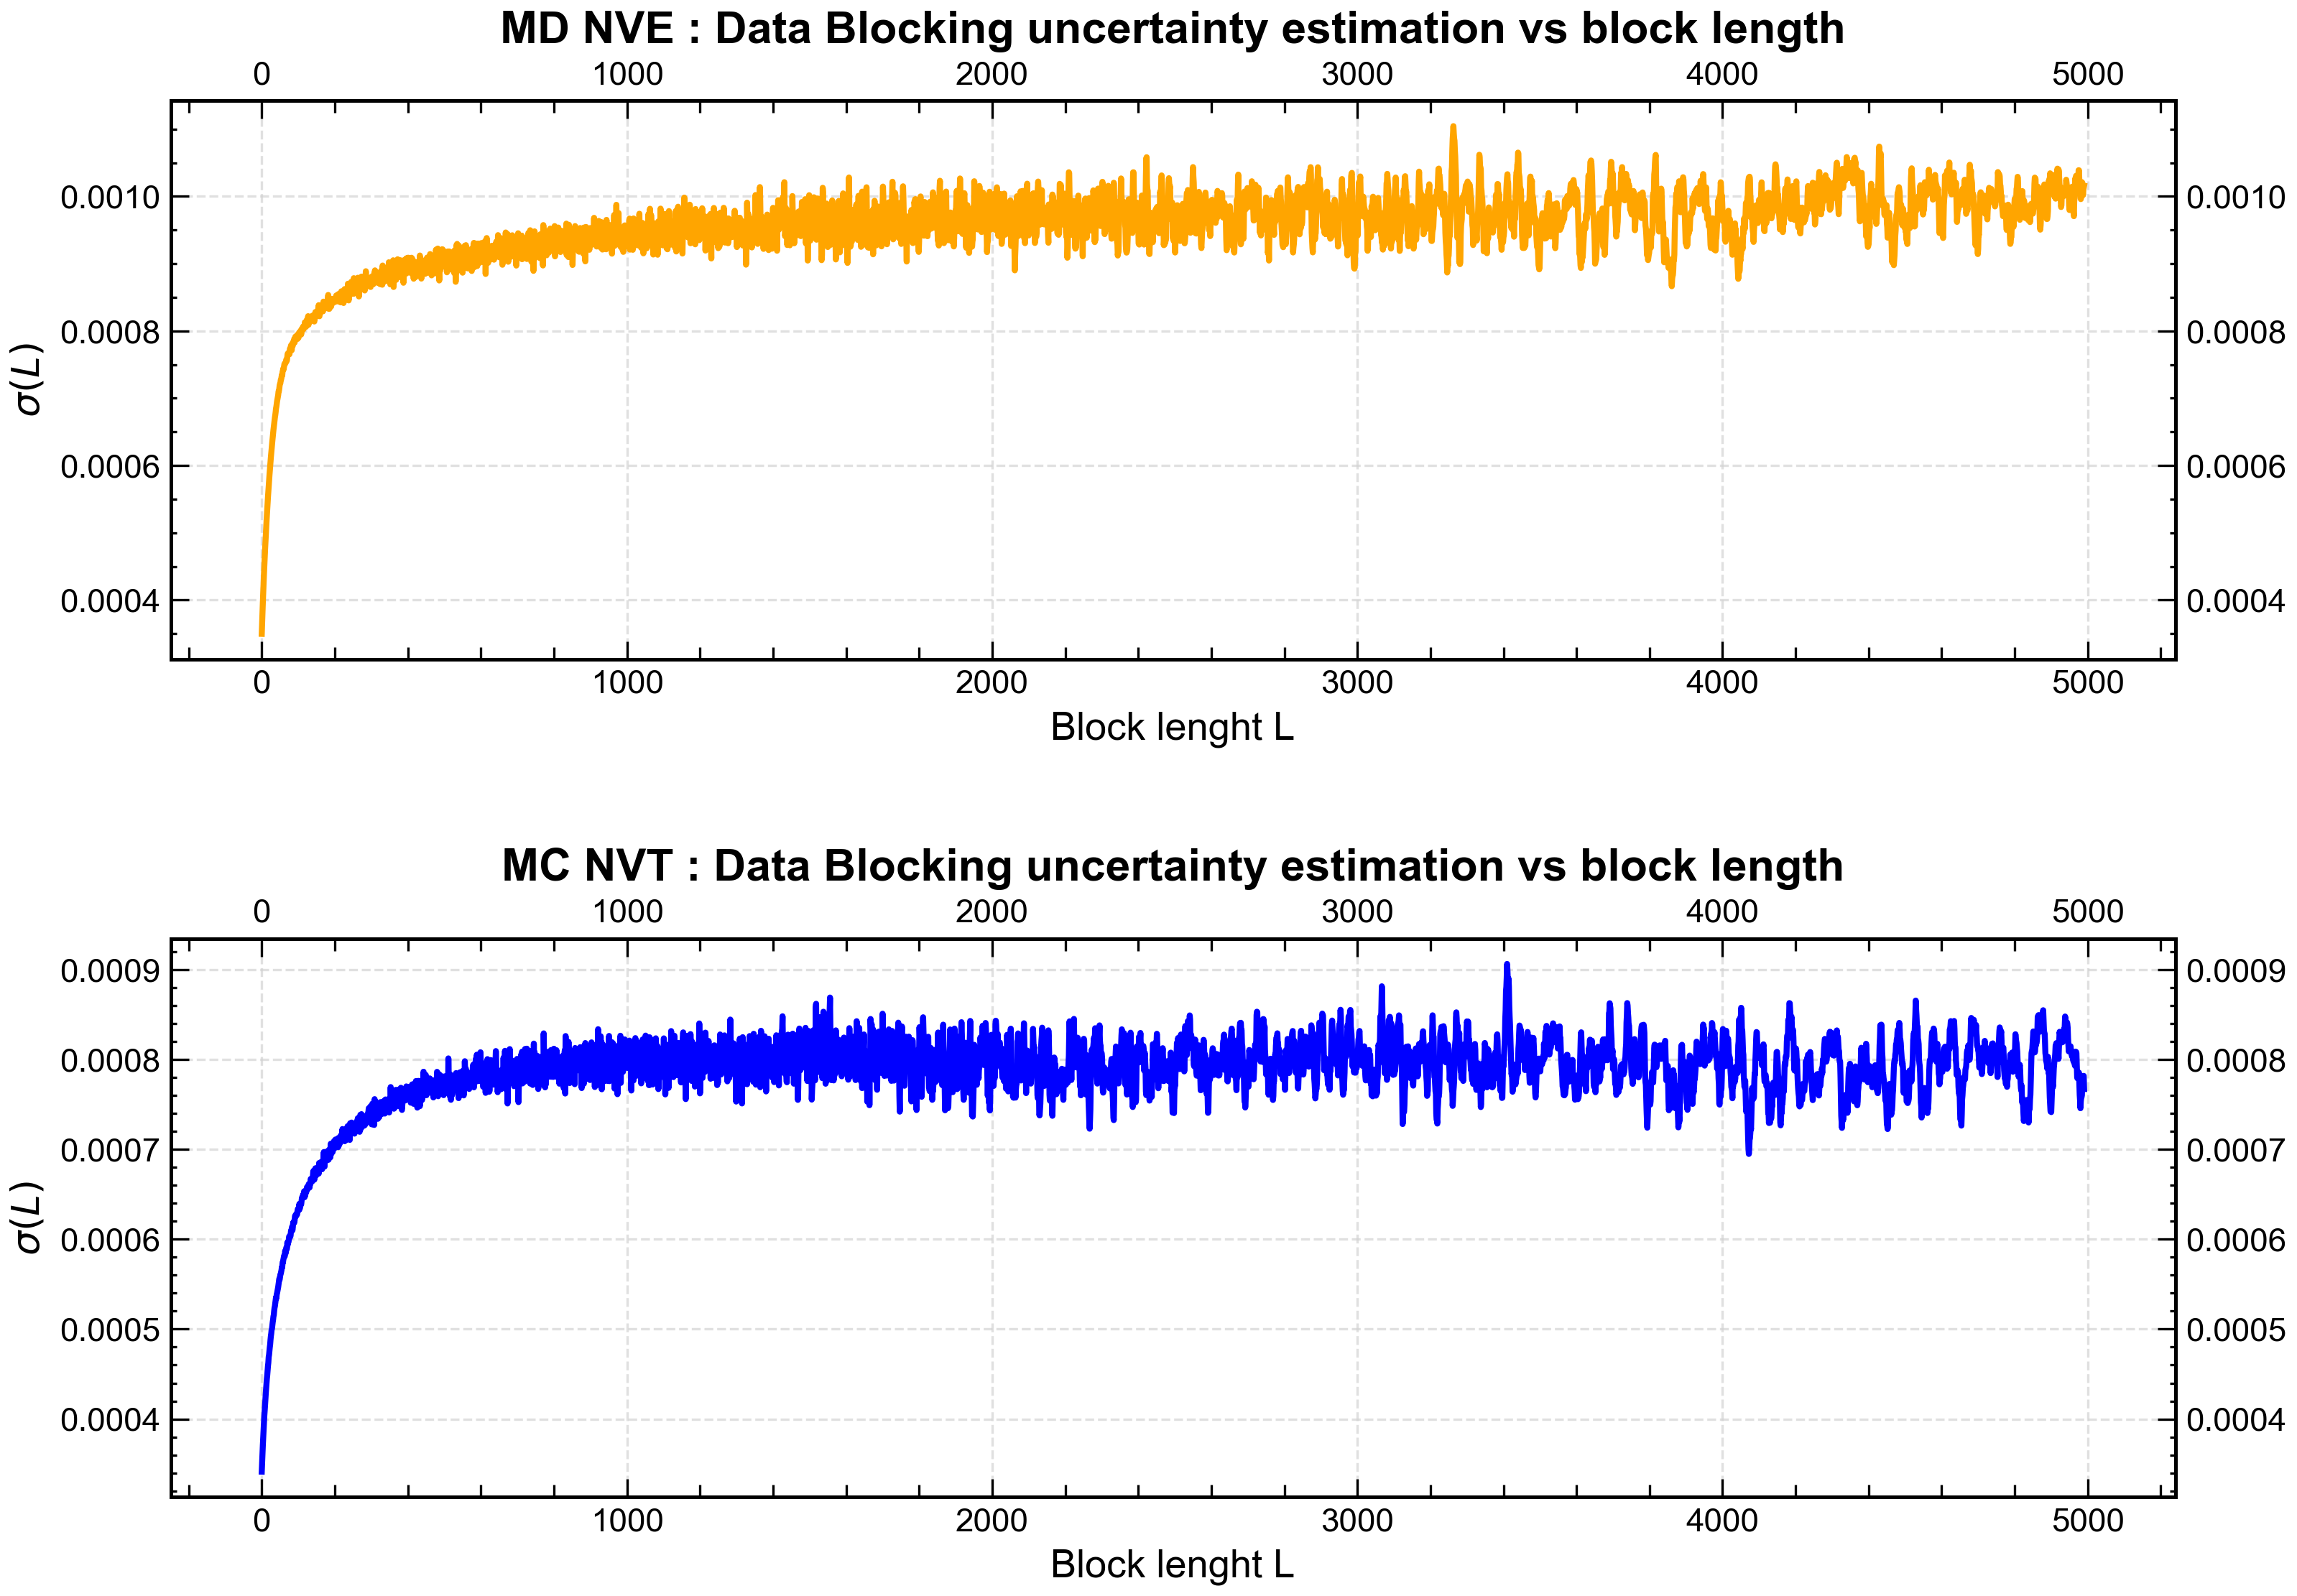

In [66]:
x = np.arange(0, len(err_NVE))

fig, axs = plt.subplots(2, 1, figsize=(12,8))

axs[0].set_title("MD NVE : Data Blocking uncertainty estimation vs block length")
axs[0].plot(x, err_NVE, color="orange")
axs[0].set_xlabel("Block lenght L")
axs[0].set_ylabel(r"$\sigma (L)$")

axs[1].set_title("MC NVT : Data Blocking uncertainty estimation vs block length")
axs[1].plot(x, err_NVT, color="blue")
axs[1].set_xlabel("Block lenght L")
axs[1].set_ylabel(r"$\sigma (L)$")

fig.subplots_adjust(
        wspace=0.3,  # Spazio orizzontale
        hspace=0.5, # Spazio verticale
        top=0.92     # move below plots (gives space to suptitle)
)
fig.savefig("plot/liquid/autocorrelation/data_block_error.png")

plt.show()

<a id="radial-distr-func"></a>

<h3><span style="color:darkviolet">Radial Distribution Function</span></h3>

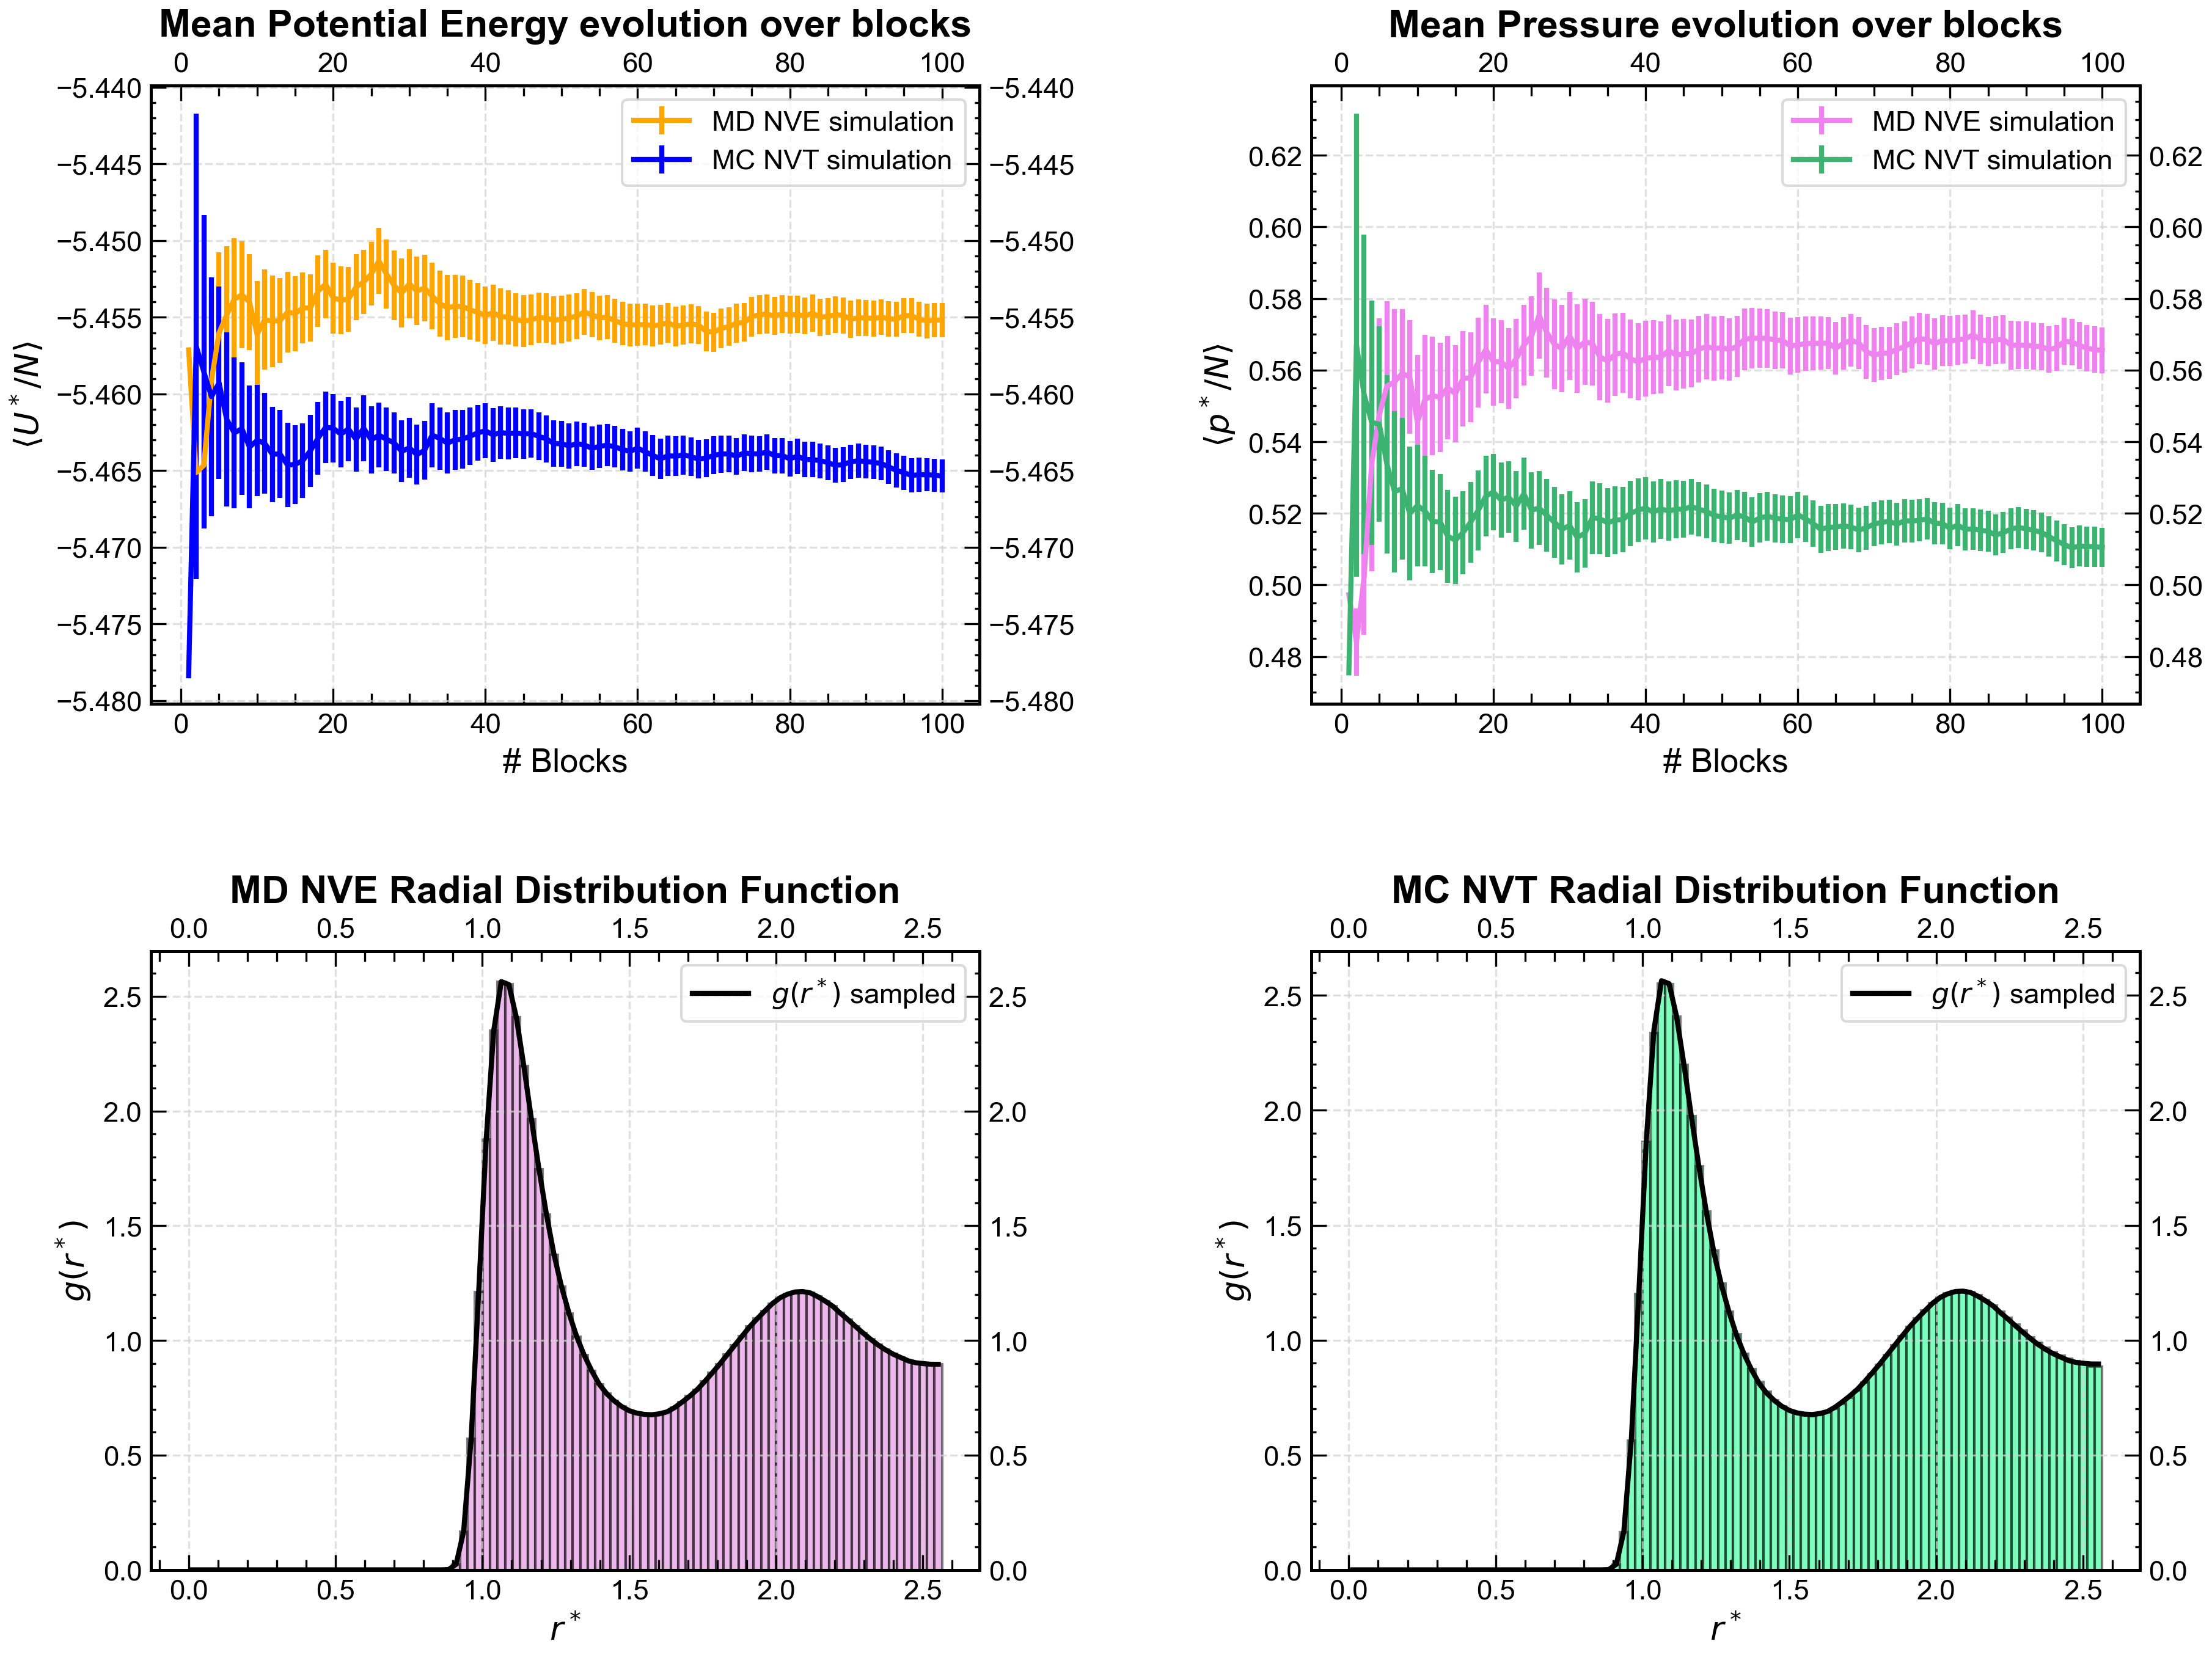

In [67]:
blocks, pot_en_NVE, pot_en_err_NVE = np.loadtxt("MD_NVE/liquid/run/OUTPUT/potential_energy.dat", usecols=(0,2,3), unpack=True)
press_NVE, press_err_NVE = np.loadtxt("MD_NVE/liquid/run/OUTPUT/pressure.dat", usecols=(2,3), unpack=True)
bin_center, gofr_NVE, gofr_err_NVE = np.loadtxt("MD_NVE/liquid/run/OUTPUT/gofr.dat", usecols=(1,3,4), unpack=True)
pot_en_NVT, pot_en_err_NVT = np.loadtxt("MC_NVT/liquid/run/OUTPUT/potential_energy.dat", usecols=(2,3), unpack=True)
press_NVT, press_err_NVT = np.loadtxt("MC_NVT/liquid/run/OUTPUT/pressure.dat", usecols=(2,3), unpack=True)
gofr_NVT, gofr_err_NVT = np.loadtxt("MC_NVT/liquid/run/OUTPUT/gofr.dat", usecols=(3,4), unpack=True)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0][0].set_title("Mean Potential Energy evolution over blocks")
axs[0][0].set_xlabel("# Blocks")
axs[0][0].set_ylabel(r"$\langle U^*/N \rangle$")
axs[0][0].errorbar(blocks, pot_en_NVE, yerr=pot_en_err_NVE, color = "orange", label="MD NVE simulation")
axs[0][0].errorbar(blocks, pot_en_NVT, yerr=pot_en_err_NVT, color = "blue", label="MC NVT simulation")
axs[0][0].legend()

axs[0][1].set_title("Mean Pressure evolution over blocks")
axs[0][1].set_xlabel("# Blocks")
axs[0][1].set_ylabel(r"$\langle p^*/N \rangle$")
axs[0][1].errorbar(blocks, press_NVE, yerr=press_err_NVE, color = "violet", label="MD NVE simulation")
axs[0][1].errorbar(blocks, press_NVT, yerr=press_err_NVT, color = "mediumseagreen", label="MC NVT simulation")
axs[0][1].legend()

axs[1][0].set_title("MD NVE Radial Distribution Function")
axs[1][0].set_xlabel(r"$r^*$")
axs[1][0].set_ylabel(r"$g(r^*)$")
axs[1][0].bar(bin_center, gofr_NVE, width=2*bin_center[0], alpha=0.5, color="orchid", edgecolor="black", yerr=gofr_err_NVE, ecolor="black")
axs[1][0].plot(bin_center, gofr_NVE, color="black", label=r"$g(r^*)$ sampled")
axs[1][0].legend()

axs[1][1].set_title("MC NVT Radial Distribution Function")
axs[1][1].set_xlabel(r"$r^*$")
axs[1][1].set_ylabel(r"$g(r^*)$")
axs[1][1].bar(bin_center, gofr_NVT, width=2*bin_center[0], alpha=0.5, color="springgreen", edgecolor="black", yerr=gofr_err_NVT, ecolor="black")
axs[1][1].plot(bin_center, gofr_NVE, color="black", label=r"$g(r^*)$ sampled")
axs[1][1].legend()

fig.subplots_adjust(
        wspace=0.4,  # Spazio orizzontale
        hspace=0.4, # Spazio verticale
        top=0.92     # move below plots (gives space to suptitle)
)

fig.savefig("plot/liquid/run/pe_pre_gofr.png")
plt.show()
